# Урок 4.1. Бустинг на остатках вручную

**Интерактивная версия:** `lessons/lesson_4_1/web/index.html`

Шесть квартир и две итерации бустинга — каждое число на виду. Затем проверяем всё кодом.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style, plot_boosting_step, plot_tree

use_course_style()

X, y = datasets.toy_regression()
x = X[:, 0]
pd.DataFrame({"площадь, ×10 м²": x, "цена, млн ₽": y})

,"площадь, ×10 м²","цена, млн ₽"
0,1.0,2.0
1,2.0,4.0
2,3.0,3.0
3,4.0,7.0
4,5.0,9.0
5,6.0,11.0


## Шаг 0. $F_0$ — среднее

In [2]:
F0 = y.mean()
print("F0 =", F0, "| сумма квадратов ошибок:", ((y - F0) ** 2).sum())

F0 = 6.0 | сумма квадратов ошибок: 64.0


## Шаг 1. Остатки и лучший пень

In [3]:
def stump_table(x, r):
    rows = []
    for t in (x[:-1] + x[1:]) / 2:
        L, R = r[x <= t], r[x > t]
        rows.append({"порог": t, "r̄_L": L.mean(), "r̄_R": R.mean(),
                     "выигрыш": len(L) * len(R) / len(r) * (L.mean() - R.mean()) ** 2})
    return pd.DataFrame(rows)


r1 = y - F0
print("остатки r(1) =", r1)
stump_table(x, r1)

остатки r(1) = [-4. -2. -3.  1.  3.  5.]


,порог,r̄_L,r̄_R,выигрыш
0,1.5,-4.0,0.8,19.2
1,2.5,-3.0,1.5,27.0
2,3.5,-3.0,3.0,54.0
3,4.5,-2.0,4.0,48.0
4,5.5,-1.0,5.0,30.0


Лучший порог 3.5: листья $-3$ и $+3$. Обновление с ν = 1: $F_1 = 6 \mp 3$.

In [4]:
h1 = np.where(x <= 3.5, r1[x <= 3.5].mean(), r1[x > 3.5].mean())
F1 = F0 + 1.0 * h1
r2 = y - F1
print("F1 =", F1, "\nr(2) =", r2, "\nсумма квадратов:", (r2**2).sum())
stump_table(x, r2)

F1 = [3. 3. 3. 9. 9. 9.] 
r(2) = [-1.  1.  0. -2.  0.  2.] 
сумма квадратов: 10.0


,порог,r̄_L,r̄_R,выигрыш
0,1.5,-1.0,0.2,1.2
1,2.5,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0
3,4.5,-0.5,1.0,3.0
4,5.5,-0.4,2.0,4.8


## Шаг 2. Второй пень: порог 5.5, листья −0.4 и +2

In [5]:
h2 = np.where(x <= 5.5, r2[x <= 5.5].mean(), r2[x > 5.5].mean())
F2 = F1 + h2
print("F2 =", F2, "| сумма квадратов:", ((y - F2) ** 2).sum())

F2 = [ 2.6  2.6  2.6  8.6  8.6 11. ] | сумма квадратов: 5.199999999999998


## Проверка кодом

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


gbcourse F2: [ 2.6  2.6  2.6  8.6  8.6 11. ]
sklearn  F2: [ 2.6  2.6  2.6  8.6  8.6 11. ]
ручной   F2: [ 2.6  2.6  2.6  8.6  8.6 11. ]


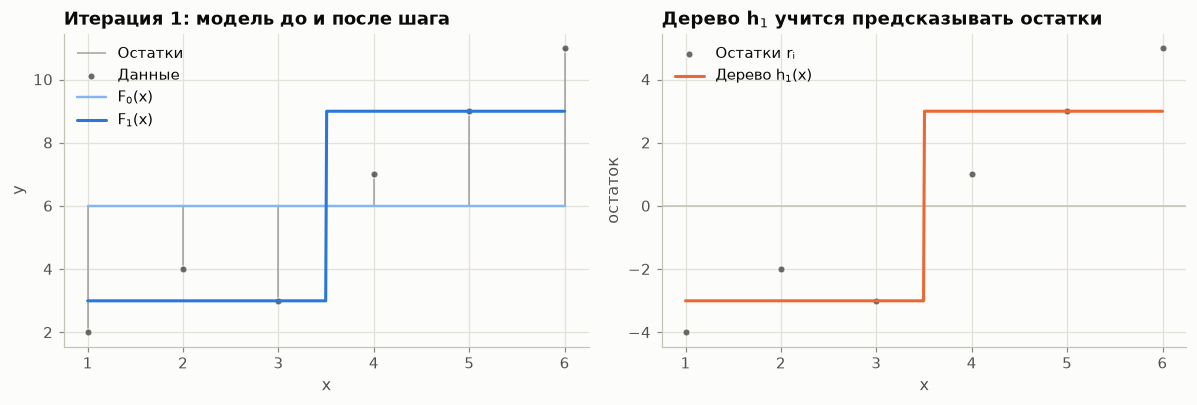

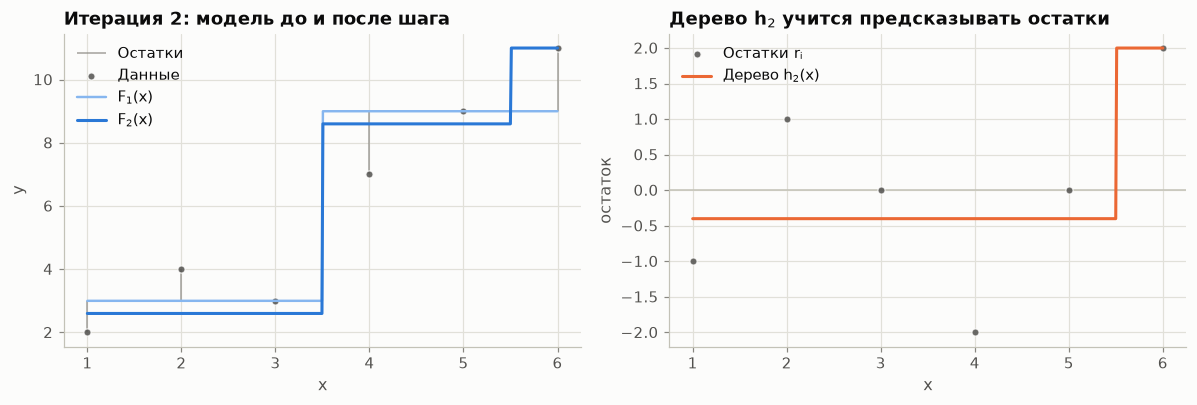

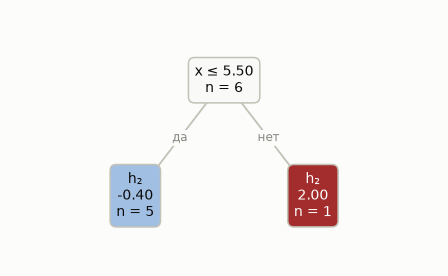

In [6]:
model = GBRegressor(n_estimators=2, learning_rate=1.0, max_depth=1).fit(X, y)
sk = GradientBoostingRegressor(n_estimators=2, learning_rate=1.0, max_depth=1).fit(X, y)
print("gbcourse F2:", model.predict(X))
print("sklearn  F2:", sk.predict(X))
print("ручной   F2:", F2)
for m in (1, 2):
    plot_boosting_step(model, X, y, m)
    plt.tight_layout()
    plt.show()
plot_tree(model.trees_[1][0], feature_names=["x"], value_label="h₂")
plt.show()

## То же с ν = 0.5

In [7]:
half = GBRegressor(n_estimators=6, learning_rate=0.5, max_depth=1).fit(X, y)
rows = []
for m, Fm in enumerate(half.staged_predict_raw(X), start=1):
    root = half.trees_[m - 1][0].nodes[0]
    rows.append({"m": m, "порог": root.threshold, "F_m": np.round(Fm, 3), "сумма квадратов": ((y - Fm) ** 2).sum()})
pd.DataFrame(rows)

,m,порог,F_m,сумма квадратов
0,1,3.5,"[4.5, 4.5, 4.5, 7.5, 7.5, 7.5]",23.500000
1,2,4.5,"[3.875, 3.875, 3.875, 6.875, 8.75, 8.75]",9.437500
2,3,5.5,"[3.65, 3.65, 3.65, 6.65, 8.525, 9.875]",4.881250
3,4,1.5,"[2.825, 3.815, 3.815, 6.815, 8.69, 10.04]",2.431000
4,5,3.5,"[2.582, 3.572, 3.572, 7.058, 8.932, 10.282]",1.372488
5,6,5.5,"[2.511, 3.501, 3.501, 6.986, 8.861, 10.641]",0.909162


## Упражнения

1. Выполните третью итерацию (ν = 1) вручную: остатки $r^{(3)}$, лучший порог, листья, $F_3$.
2. Для ν = 0.5 какой порог выберет второе дерево? Объясните, почему не 3.5.
3. Замените y₆ = 11 на 20. Как изменятся $F_0$ и первое дерево?

Решения: `python lessons/lesson_4_1/exercises/solutions.py`.